In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


/opt/homebrew/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
np.random.seed(42)
tf.random.set_seed(42)


In [3]:
# Features
hours_studied = np.random.uniform(0, 10, 500)
sleep_hours = np.random.uniform(4, 9, 500)

X = np.column_stack([hours_studied, sleep_hours])

# Target logic (simple, explainable)
y = ((hours_studied > 4) & (sleep_hours > 6)).astype(int)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
def build_model(lr):
    model = Sequential([
        Dense(16, activation='relu', input_shape=(2,)),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [6]:
model_high = build_model(0.01)
hist_high = model_high.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model_mid = build_model(0.001)
hist_mid = model_mid.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)


In [8]:
model_low = build_model(0.0001)
hist_low = model_low.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)


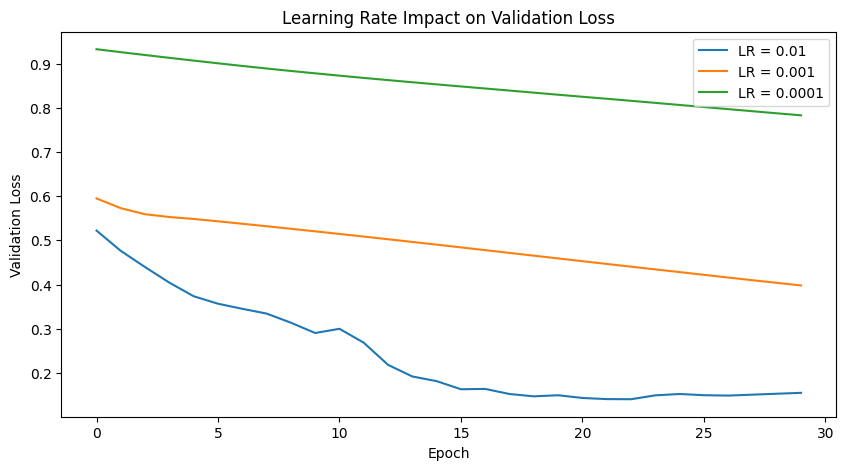

In [9]:
plt.figure(figsize=(10,5))

plt.plot(hist_high.history['val_loss'], label='LR = 0.01')
plt.plot(hist_mid.history['val_loss'], label='LR = 0.001')
plt.plot(hist_low.history['val_loss'], label='LR = 0.0001')

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Learning Rate Impact on Validation Loss')
plt.legend()
plt.show()


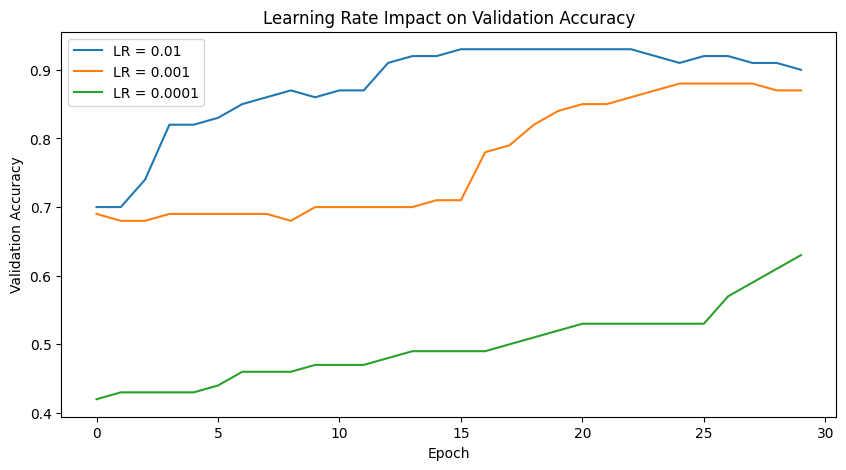

In [10]:
plt.figure(figsize=(10,5))

plt.plot(hist_high.history['val_accuracy'], label='LR = 0.01')
plt.plot(hist_mid.history['val_accuracy'], label='LR = 0.001')
plt.plot(hist_low.history['val_accuracy'], label='LR = 0.0001')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Learning Rate Impact on Validation Accuracy')
plt.legend()
plt.show()


In [16]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.01),  # intentionally high
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [18]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)


In [19]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[lr_scheduler],
    verbose=1
)


Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5875 - loss: 0.6634 - val_accuracy: 0.7000 - val_loss: 0.5688 - learning_rate: 0.0100
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6700 - loss: 0.5405 - val_accuracy: 0.7000 - val_loss: 0.5120 - learning_rate: 0.0100
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.4947 - val_accuracy: 0.7100 - val_loss: 0.4830 - learning_rate: 0.0100
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7050 - loss: 0.4620 - val_accuracy: 0.7100 - val_loss: 0.4559 - learning_rate: 0.0100
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7275 - loss: 0.4246 - val_accuracy: 0.7300 - val_loss: 0.4268 - learning_rate: 0.0100
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8375 - loss: 0.3855 - val_accuracy: 0.8100 - val_loss: 0.3882 - learning_rate: 0.0100
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8575 - loss: 0.3304 - val_accuracy:

In [20]:
print("Final Learning Rate:", model.optimizer.learning_rate.numpy())


Final Learning Rate: 0.005


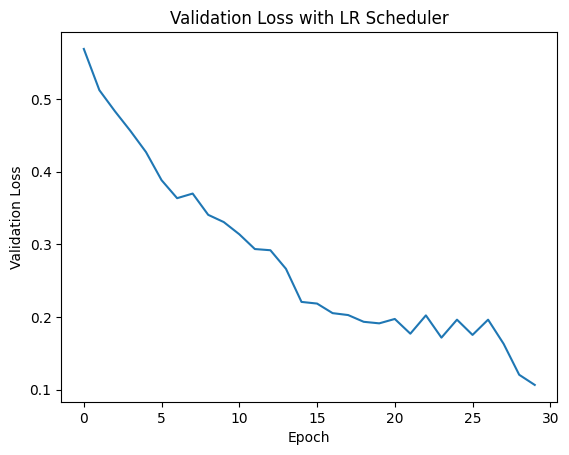

In [21]:
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss with LR Scheduler")
plt.show()
